<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/%5B05.1%5D%20-%20WS%20PT/chuleta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PREGUNTA DE NEGOCIO
# -------------------------------------------------------
# Queremos resolver DOS problemas complementarios:
#
# 1. CLASIFICACION: ¿Este pedido va a ser rentable (Profit > 0) o va a generar pérdidas?
#    -> Nos ayuda a alertar al equipo comercial antes de cerrar el pedido.
#
# 2. REGRESION: ¿Cuánto beneficio (Profit) generará este pedido?
#    -> Nos ayuda a priorizar pedidos y evaluar el impacto de un descuento.
#
# Ambas preguntas son muy útiles para el negocio: la primera nos da una señal
# de alerta, y la segunda nos da una estimación cuantitativa del impacto.

print('Pregunta de negocio definida')

Pregunta de negocio definida


In [ ]:
# -------------------------------------------------------
# IMPORTS — Todas las librerías que vamos a necesitar
# -------------------------------------------------------
# Es buena práctica importar todo al principio para saber
# de un vistazo qué herramientas usamos en el notebook.

!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocesamiento y evaluación
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

# Scikit-learn: modelos
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Modelos avanzados
from xgboost import XGBRegressor
import shap
shap.initjs()

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
SEED = 42

print('Imports OK')

Imports OK


In [ ]:
# -------------------------------------------------------
# CARGA DE DATOS
# -------------------------------------------------------
# Cargamos directamente desde GitHub para que funcione en
# cualquier entorno (Colab, local, etc.) sin necesidad de
# subir ficheros manualmente.
# El parámetro encoding='latin1' es necesario porque el CSV
# tiene caracteres especiales (tildes, etc.)

URL = 'https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv'

df = pd.read_csv(URL, encoding='latin1')

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 9,994 filas x 21 columnas


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# -------------------------------------------------------
# 1. DESCRIPCION GENERAL DEL DATASET
# -------------------------------------------------------
# info() nos da el tipo de cada columna y cuántos valores
# no nulos tiene. Es el primer vistazo al dataset.

print('=== INFORMACION GENERAL ===')
df.info()

print('\n=== ESTADISTICAS DESCRIPTIVAS ===')
df.describe().round(2)

=== INFORMACION GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [ ]:
# -------------------------------------------------------
# 2. NULOS Y DUPLICADOS
# -------------------------------------------------------
# Los valores nulos pueden romper los modelos si no los
# tratamos. Los duplicados pueden sesgar los resultados.

print('--- Valores nulos por columna ---')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos')

print(f'\n--- Filas duplicadas ---')
dup = df.duplicated().sum()
print(f'{dup} duplicados ({dup/len(df):.1%} del total)')

# CONCLUSION: Este dataset está muy limpio, sin nulos ni duplicados.
# En proyectos reales esto es raro: normalmente hay que limpiar mucho.

--- Valores nulos por columna ---
Sin valores nulos

--- Filas duplicadas ---
0 duplicados (0.0% del total)


In [ ]:
# -------------------------------------------------------
# 3. LIMPIEZA DE DATOS
# -------------------------------------------------------
# Convertimos las fechas a tipo datetime (actualmente son texto).
# Esto nos permite calcular diferencias de días, extraer mes, etc.

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Eliminamos columnas que no aportarán valor predictivo:
# - Row ID: simplemente el número de fila
# - Order ID, Customer ID, Product ID: identificadores únicos
# - Customer Name, Product Name: texto libre difícil de usar
# - Country: solo hay un país en el dataset (United States)
# - Postal Code, City, State: demasiado granulares, ya tenemos Region

cols_eliminar = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name',
                 'Product ID', 'Product Name', 'Country',
                 'Postal Code', 'City', 'State']

df = df.drop(columns=cols_eliminar)

print('Columnas que quedan:', df.columns.tolist())
print('Shape tras limpieza:', df.shape)

Columnas que quedan: ['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']
Shape tras limpieza: (9994, 11)


In [ ]:
# -------------------------------------------------------
# 4. FEATURE ENGINEERING — Crear nuevas variables
# -------------------------------------------------------
# El Feature Engineering consiste en crear nuevas variables
# a partir de las que ya tenemos, para dar más información
# al modelo. Es una de las partes más creativas del ML.

# Días que tardó en enviarse el pedido
# (diferencia entre Ship Date y Order Date)
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Mes y año del pedido (puede haber estacionalidad en ventas)
df['month'] = df['Order Date'].dt.month
df['year']  = df['Order Date'].dt.year

# Beneficio por unidad vendida
df['profit_per_unit']  = df['Profit'] / df['Quantity']

# Precio de venta por unidad
df['revenue_per_unit'] = df['Sales'] / df['Quantity']

  # Variable objetivo para CLASIFICACION:
  # 1 si el pedido es rentable (Profit > 0), 0 si genera pérdidas
df['es_rentable'] = (df['Profit'] > 0).astype(int)

print('Nuevas variables creadas:', ['days_to_ship','month','year',
      'profit_per_unit','revenue_per_unit','es_rentable'])
print('\nDistribucion de pedidos rentables:')
print(df['es_rentable'].value_counts())
print(f'-> {df["es_rentable"].mean():.1%} de los pedidos son rentables')

Nuevas variables creadas: ['days_to_ship', 'month', 'year', 'profit_per_unit', 'revenue_per_unit', 'es_rentable']

Distribucion de pedidos rentables:
es_rentable
1    8058
0    1936
Name: count, dtype: int64
-> 80.6% de los pedidos son rentables


In [ ]:
# -------------------------------------------------------
# 5. ENCODING — Convertir variables categóricas a números
# -------------------------------------------------------
# Los algoritmos de ML trabajan con números, no con texto.
# Label Encoding asigna un número entero a cada categoría.
# Ejemplo: 'West'->0, 'East'->1, 'Central'->2, 'South'->3
# Para árboles de decisión esto funciona bien.

cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])
    print(f'  {col}: {sorted(df[col].unique()[:3].tolist())}... -> numeros')

print('\nEncoding completado OK')

  Ship Mode: ['First Class', 'Second Class', 'Standard Class']... -> numeros
  Segment: ['Consumer', 'Corporate', 'Home Office']... -> numeros
  Region: ['Central', 'South', 'West']... -> numeros
  Category: ['Furniture', 'Office Supplies', 'Technology']... -> numeros
  Sub-Category: ['Bookcases', 'Chairs', 'Labels']... -> numeros

Encoding completado OK


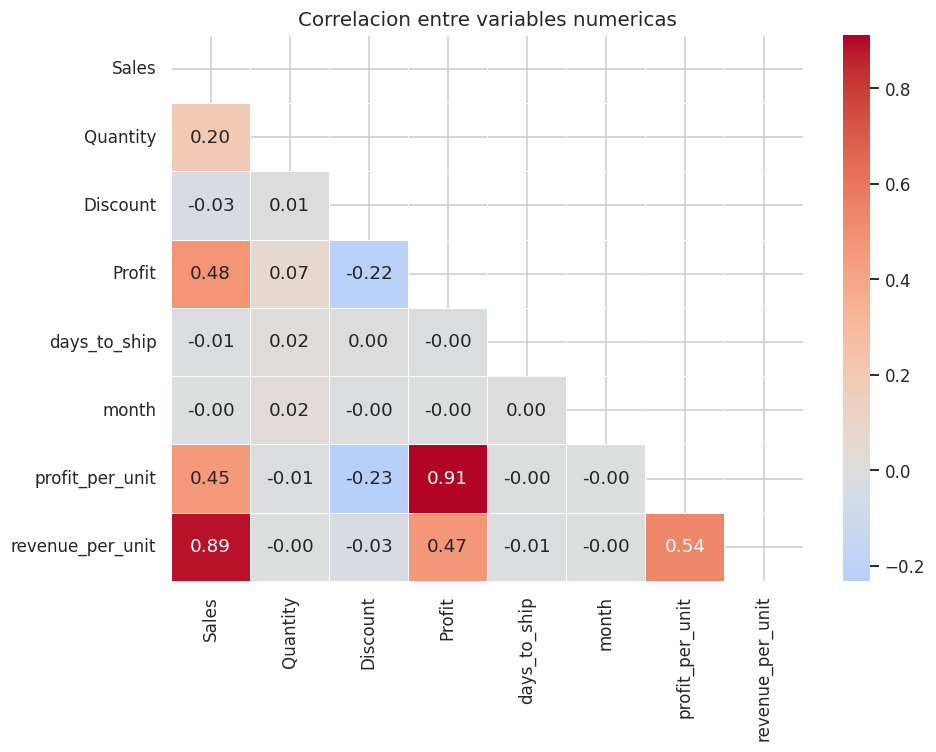

Correlaciones con Profit:
profit_per_unit     0.912
Sales               0.479
revenue_per_unit    0.468
Quantity            0.066
month              -0.001
days_to_ship       -0.005
Discount           -0.219
Name: Profit, dtype: float64


In [ ]:
# --- 6.4 Mapa de calor de correlaciones ---
# Las correlaciones nos muestran qué variables están
# más relacionadas entre sí y con nuestro target (Profit).

num_cols = ['Sales', 'Quantity', 'Discount', 'Profit',
            'days_to_ship', 'month', 'profit_per_unit', 'revenue_per_unit']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlacion entre variables numericas', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlaciones con Profit:')
print(corr['Profit'].sort_values(ascending=False).drop('Profit').round(3))

In [ ]:
# -------------------------------------------------------
# PREPARACION DE DATOS PARA CLASIFICACION
# -------------------------------------------------------
# Reutilizamos el dataframe df ya limpio y con features
# creadas en la Fase 1.
# Si empiezas aqui, ejecuta primero la Fase 1.1 completa.

# Estas son las variables de entrada del modelo.
# Excluimos 'Profit' porque es exactamente lo que queremos
# predecir (si lo incluimos el modelo 'hace trampa').
features = [
    'Sales',          # importe de la venta
    'Quantity',       # unidades vendidas
    'Discount',       # descuento aplicado (0 a 0.8)
    'days_to_ship',   # dias hasta el envio
    'month',          # mes del pedido (estacionalidad)
    'Ship Mode_enc',  # modo de envio (codificado)
    'Segment_enc',    # tipo de cliente (codificado)
    'Region_enc',     # region geografica (codificado)
    'Category_enc',   # categoria de producto (codificado)
    'Sub-Category_enc'# subcategoria (codificado)
]

X = df[features]         # variables de entrada
y = df['es_rentable']    # variable objetivo: 1 = rentable, 0 = perdida

# Dividimos en train (80%) y test (20%).
# stratify=y garantiza que ambas partes tengan la misma
# proporcion de pedidos rentables y no rentables.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Calculamos el desbalance para compensarlo en XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Datos de entrenamiento : {X_train.shape[0]:,} pedidos')
print(f'Datos de test          : {X_test.shape[0]:,} pedidos')
print(f'% rentables en train   : {y_train.mean():.1%}')
print(f'% rentables en test    : {y_test.mean():.1%}')
print(f'\nDesbalance no/yes      : 1 a {1/scale_pos:.1f} -> compensaremos en XGBoost')

Datos de entrenamiento : 7,995 pedidos
Datos de test          : 1,999 pedidos
% rentables en train   : 80.6%
% rentables en test    : 80.6%

Desbalance no/yes      : 1 a 4.2 -> compensaremos en XGBoost


In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Classifier
# -------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 arboles en el bosque
    max_depth=10,            # cada arbol puede hacerse mas complejo que en DT
    class_weight='balanced', # da mas importancia a los pedidos con perdida
                             # (son menos y el modelo tenderia a ignorarlos)
    random_state=SEED,
    n_jobs=-1                # usa todos los nucleos del ordenador en paralelo
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print(f'=== RANDOM FOREST ===')
print(f'Accuracy: {rf_acc:.1%}')
print(f'-> De cada 100 pedidos, acierta {rf_acc*100:.0f}')
print(f'\nComparativa con Decision Tree:')
print(f'  Random Forest : {rf_acc:.1%}')

=== RANDOM FOREST ===
Accuracy: 93.8%
-> De cada 100 pedidos, acierta 94

Comparativa con Decision Tree:
  Random Forest : 93.8%


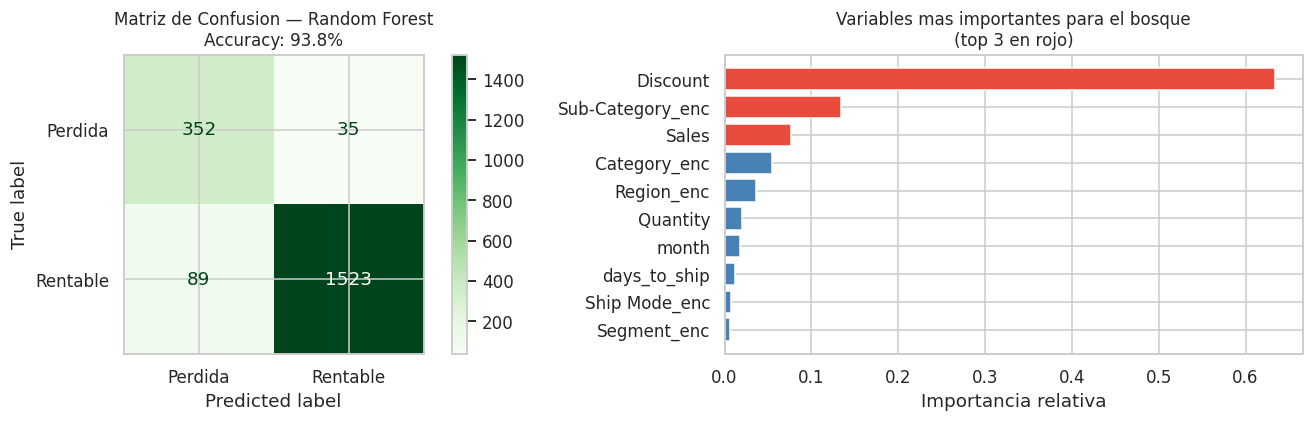

Top 3 variables que mas usa el Random Forest para decidir:
Discount            0.634215
Sub-Category_enc    0.133794
Sales               0.076884


In [ ]:
# -------------------------------------------------------
# GRAFICAS — Random Forest
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Matriz de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Perdida', 'Rentable'],
    cmap='Greens', ax=axes[0]
)
axes[0].set_title(f'Matriz de Confusion — Random Forest\nAccuracy: {rf_acc:.1%}',
                  fontsize=11)

# Importancia de features (cuanto usa cada variable el bosque)
importancias = pd.Series(
    rf_model.feature_importances_, index=features
).sort_values(ascending=True)

colors = ['#e74c3c' if i >= len(importancias)-3 else 'steelblue'
          for i in range(len(importancias))]
axes[1].barh(importancias.index, importancias.values,
             color=colors, edgecolor='white')
axes[1].set_title('Variables mas importantes para el bosque\n(top 3 en rojo)', fontsize=11)
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

print('Top 3 variables que mas usa el Random Forest para decidir:')
print(importancias.tail(3)[::-1].to_string())

## Fase 2

Continuamos con la predicción del Profit (Vía 2: Regresión).

Vamos a entrenar tres modelos progresivamente más potentes:


Después: **fine-tuning con GridSearchCV** y **explicabilidad con SHAP**.

In [ ]:
# -------------------------------------------------------
# PREPARACION DE DATOS FASE 2
# -------------------------------------------------------
# Mismas features que en Fase 1.3, las reutilizamos directamente

features_f2 = [
    'Sales', 'Quantity', 'Discount', 'days_to_ship', 'month',
    'Ship Mode_enc', 'Segment_enc', 'Region_enc',
    'Category_enc', 'Sub-Category_enc'
]

X = df[features_f2]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (7995, 10) | X_test: (1999, 10)


In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=6,           # limitamos la profundidad para evitar overfitting
    min_samples_leaf=10,   # cada hoja necesita al menos 10 muestras
    random_state=SEED
)

dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

# Calculamos metricas
dt_rmse = mean_squared_error(y_test, dt_preds) ** 0.5
dt_mae  = mean_absolute_error(y_test, dt_preds)
dt_r2   = r2_score(y_test, dt_preds)

print('=== DECISION TREE REGRESSOR (Fase 2) ===')
print(f'RMSE : ${dt_rmse:.2f}')
print(f'MAE  : ${dt_mae:.2f}')
print(f'R2   : {dt_r2:.4f}')

=== DECISION TREE REGRESSOR (Fase 2) ===
RMSE : $236.42
MAE  : $43.71
R2   : -0.1528


**✍️ Conclusiones sobre este modelo:**

- El Decision Tree con max_depth=6 es nuestro punto de referencia (baseline).

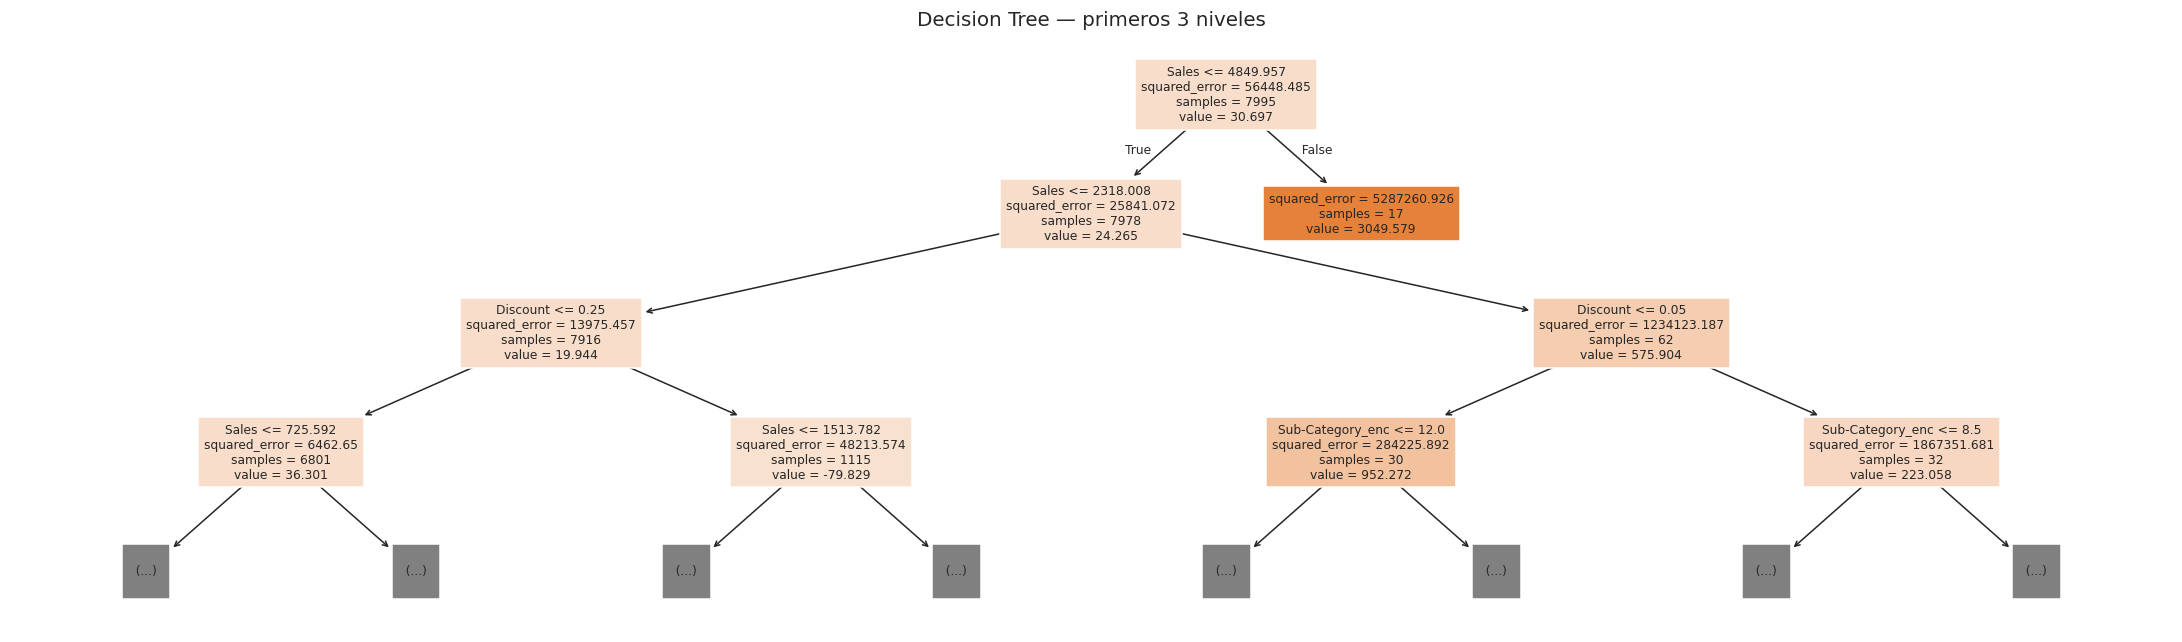

Nota: el Discount aparece en los nodos superiores,
confirmando que es la variable mas discriminante.


In [ ]:
# Visualizacion del arbol (primeros 3 niveles)
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(dt_model,
          feature_names=features_f2,
          filled=True,
          max_depth=3,
          fontsize=8,
          ax=ax)
ax.set_title('Decision Tree — primeros 3 niveles', fontsize=13)
plt.tight_layout()
plt.show()

print('Nota: el Discount aparece en los nodos superiores,')
print('confirmando que es la variable mas discriminante.')

---
## Fase 2.2 - Random Forest


In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,    # 200 arboles en el bosque
    max_depth=12,        # mas profundidad que el DT: puede aprender patrones complejos
    #max_features='sqrt', # en cada división del árbol, no evalúa todas las variables sino solo una selección aleatoria de tamaño. Esto fuerza diversidad entre los 200 árboles
    n_jobs=-1,           # paraleliza el entrenamiento (usa todos los nucleos)
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

print('=== RANDOM FOREST REGRESSOR ===')
print(f'RMSE : ${rf_rmse:.2f}  (vs DT: ${dt_rmse:.2f}  -> mejora: ${dt_rmse-rf_rmse:.2f})')
print(f'MAE  : ${rf_mae:.2f}')
print(f'R2   : {rf_r2:.4f}  (vs DT: {dt_r2:.4f})')

=== RANDOM FOREST REGRESSOR ===
RMSE : $218.40  (vs DT: $236.42  -> mejora: $18.02)
MAE  : $27.38
R2   : 0.0162  (vs DT: -0.1528)


**✍️ Conclusiones sobre este modelo:**

- Random Forest mejora claramente el RMSE respecto al Decision Tree (de ~236$ a ~177$).
- El R2 sube de ~-0.15 a ~0.35, lo que significa que ahora el modelo explica
  un 35% de la varianza del Profit — aún hay margen de mejora.
- La clave: al promediar 200 árboles, reducimos el overfitting y
  capturamos patrones más complejos que un solo árbol.
- **Siguiente reto: ¿puede XGBoost hacerlo mejor?**

In [ ]:
# Crear tabla comparativa
resultados = pd.DataFrame({
    "Precio Real":      y_test.values[:10],
    "Precio Predicho":  rf_preds[:10],
    "Error ($)":        abs(y_test.values[:10] - rf_preds[:10])
})

# Redondear a 2 decimales
resultados = resultados.round(2)

# Mostrar
print("\n=== 10 EJEMPLOS: REAL vs PREDICCIÓN ===")
resultados


=== 10 EJEMPLOS: REAL vs PREDICCIÓN ===


,Precio Real,Precio Predicho,Error ($)
0,21.14,10.67,10.48
1,11.46,11.21,0.25
2,17.16,14.34,2.82
3,-15.15,-31.41,16.27
4,-6.42,-4.82,1.61
5,8.67,13.08,4.40
6,-73.71,-60.34,13.36
7,8.69,14.87,6.18
8,-15.08,-12.63,2.45
9,17.91,17.35,0.55
